# 01 – Coordinate Exploration

**Purpose:** Load and inspect the BGA coordinate file, apply the bottom-view mirror transform,
verify the expected ball count, and visualise the ball grid.

**Corresponds to:** AGENTS.md Step 3.1 and Test Step 4.1

**Key facts (from Step 1 research):**
- Coordinate file: `database/<package>/coordinates/*.xlsx`, sheet `BGA`
- Row 2 is always blank — skip it (read from row 3 onward)
- Columns: `BGA Number`, `X Coord` (µm), `Y Coord` (µm)
- Expected ball count: **2 077** for package FP11
- Bottom-view mirror transform: `x_bv = -X_coord`, `y_bv = Y_coord`
- Ball pitch: **800 µm**
- Array extents: X ±17 450 µm, Y ±21 200 µm

## 0. Configuration

In [1]:
from pathlib import Path

# ── Edit this to switch package ──────────────────────────────────────────────
PACKAGE = "FP11_BLTC"
# ─────────────────────────────────────────────────────────────────────────────

REPO_ROOT   = Path("../..").resolve()
COORD_DIR   = REPO_ROOT / "database" / PACKAGE / "coordinates"
COORD_FILE  = next(COORD_DIR.glob("*.xlsx"))   # pick the first (only) xlsx
SHEET_NAME  = "BGA"
FIRST_DATA_ROW = 3   # row 1 = header, row 2 = blank

print(f"Package      : {PACKAGE}")
print(f"Coordinate file: {COORD_FILE.name}")

Package      : FP11_BLTC
Coordinate file: BGA x,y coordinates FP11.xlsx


## 1. Load coordinate data

In [2]:
import pandas as pd
import openpyxl

wb = openpyxl.load_workbook(COORD_FILE, data_only=True, read_only=True)
ws = wb[SHEET_NAME]

data = [
    row
    for row in ws.iter_rows(min_row=FIRST_DATA_ROW, values_only=True)
    if row[0] is not None   # skip any trailing blank rows
]
wb.close()

df = pd.DataFrame(data, columns=["BGA_Number", "X_Coord", "Y_Coord"])
df["X_Coord"] = df["X_Coord"].astype(int)
df["Y_Coord"] = df["Y_Coord"].astype(int)

print(df.head(10))
print(f"\nShape: {df.shape}")

  BGA_Number  X_Coord  Y_Coord
0        A10   -10000    21200
1        A11    -9200    21200
2        A12    -8400    21200
3        A13    -7600    21200
4        A14    -6800    21200
5        A15    -6000    21200
6        A16    -5200    21200
7        A17    -4400    21200
8        A18    -3600    21200
9        A19    -2800    21200

Shape: (2077, 3)


## 2. Sanity checks (Test 4.1)

In [3]:
EXPECTED_BALLS = 2077

# ── Check 1: ball count ──────────────────────────────────────────────────────
n_balls = len(df)
status_count = "PASS" if n_balls == EXPECTED_BALLS else "FAIL"
print(f"[{status_count}] Ball count: {n_balls} (expected {EXPECTED_BALLS})")

# ── Check 2: X range symmetry ────────────────────────────────────────────────
x_min, x_max = df["X_Coord"].min(), df["X_Coord"].max()
status_sym = "PASS" if x_min == -x_max else "FAIL"
print(f"[{status_sym}] X range: {x_min} to {x_max} µm  (symmetric: {x_min == -x_max})")

y_min, y_max = df["Y_Coord"].min(), df["Y_Coord"].max()
print(f"      Y range: {y_min} to {y_max} µm")

# ── Check 3: unique positions and pitch ──────────────────────────────────────
import statistics
ux = sorted(df["X_Coord"].unique())
uy = sorted(df["Y_Coord"].unique())
x_pitch = statistics.mode([ux[i+1] - ux[i] for i in range(len(ux)-1)])
y_pitch = statistics.mode([uy[i+1] - uy[i] for i in range(len(uy)-1)])
status_pitch = "PASS" if x_pitch == 800 and y_pitch == 800 else "WARN"
print(f"[{status_pitch}] Grid: {len(ux)} unique X × {len(uy)} unique Y positions")
print(f"      Common pitch: X={x_pitch} µm, Y={y_pitch} µm (expected 800 µm)")

# ── Check 4: no missing values ───────────────────────────────────────────────
n_null = df.isnull().sum().sum()
status_null = "PASS" if n_null == 0 else "FAIL"
print(f"[{status_null}] Missing values: {n_null}")

[PASS] Ball count: 2077 (expected 2077)
[PASS] X range: -17450 to 17450 µm  (symmetric: True)
      Y range: -21200 to 21200 µm
[PASS] Grid: 63 unique X × 77 unique Y positions
      Common pitch: X=800 µm, Y=800 µm (expected 800 µm)
[PASS] Missing values: 0


## 3. Apply bottom-view mirror transform

In [4]:
# Bottom-view: package viewed from below → X axis is mirrored relative to top-down.
# Reference corner moves from top-left (coordinates) to top-right (image).
# Transform: x_bv = -X_Coord,  y_bv = Y_Coord  (Y unchanged)

df["X_bv"] = -df["X_Coord"]
df["Y_bv"] =  df["Y_Coord"]

# Verify: mirrored X range should equal negative of original
assert df["X_bv"].min() == -x_max, "Mirror sanity check failed"
assert df["X_bv"].max() == -x_min, "Mirror sanity check failed"
print("Mirror transform applied and verified.")
print(f"  Original  X range: {x_min} to {x_max} µm")
print(f"  Mirrored  X range: {df['X_bv'].min()} to {df['X_bv'].max()} µm")
print(f"  Y range (unchanged): {y_min} to {y_max} µm")
print()
print(df[["BGA_Number", "X_Coord", "Y_Coord", "X_bv", "Y_bv"]].head(8))

Mirror transform applied and verified.
  Original  X range: -17450 to 17450 µm
  Mirrored  X range: -17450 to 17450 µm
  Y range (unchanged): -21200 to 21200 µm

  BGA_Number  X_Coord  Y_Coord   X_bv   Y_bv
0        A10   -10000    21200  10000  21200
1        A11    -9200    21200   9200  21200
2        A12    -8400    21200   8400  21200
3        A13    -7600    21200   7600  21200
4        A14    -6800    21200   6800  21200
5        A15    -6000    21200   6000  21200
6        A16    -5200    21200   5200  21200
7        A17    -4400    21200   4400  21200


## 4. Visualise the ball grid

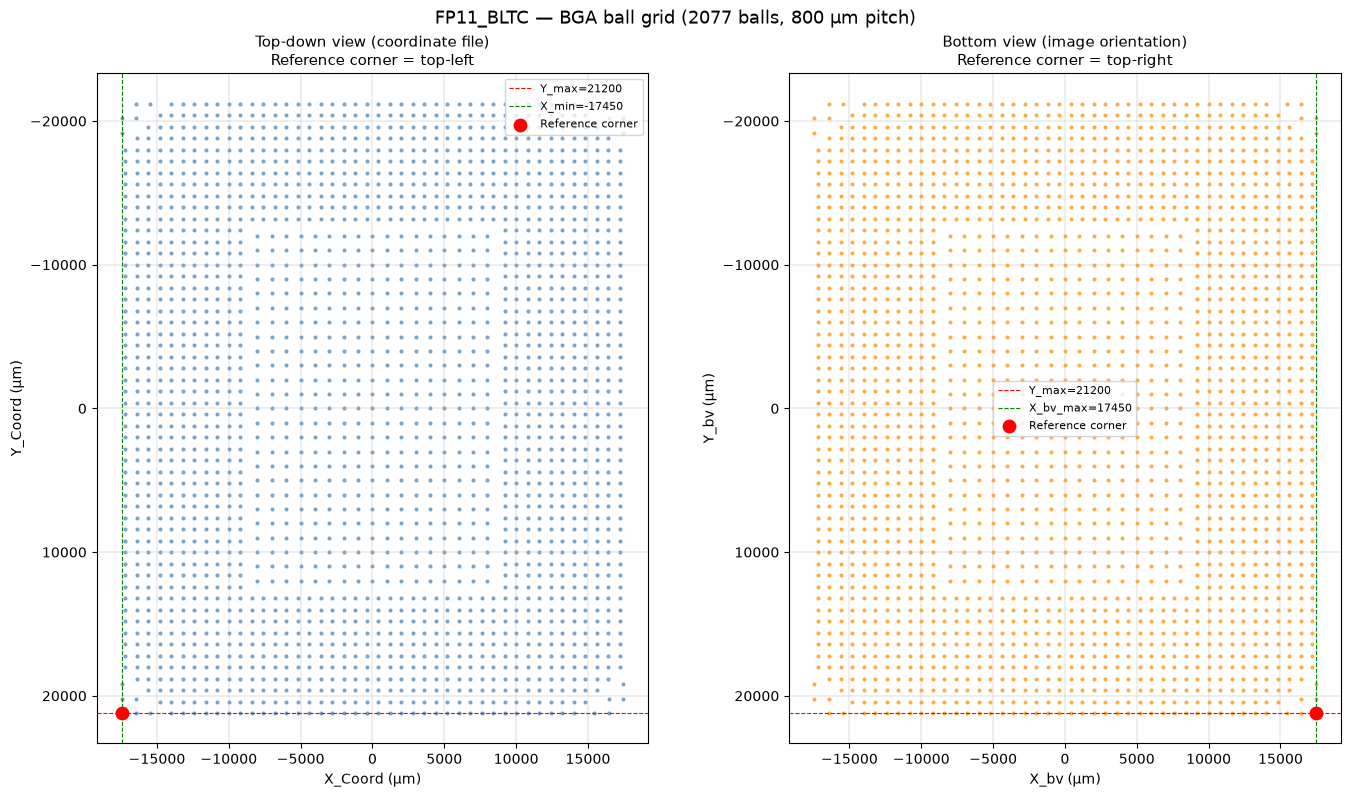

Visual check: left plot reference corner (red dot) should be top-left.
              right plot reference corner (red dot) should be top-right.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# ── Left: top-down view (coordinate file orientation) ────────────────────────
ax = axes[0]
ax.scatter(df["X_Coord"], df["Y_Coord"], s=4, c="steelblue", alpha=0.6)
ax.set_title("Top-down view (coordinate file)\nReference corner = top-left", fontsize=11)
ax.set_xlabel("X_Coord (µm)")
ax.set_ylabel("Y_Coord (µm)")
ax.invert_yaxis()   # image convention: Y increases downward
ax.axhline(y_max, color="red",  lw=0.8, ls="--", label=f"Y_max={y_max}")
ax.axvline(x_min, color="green",lw=0.8, ls="--", label=f"X_min={x_min}")
# mark reference corner (top-left in top-down view = min X, max Y)
ax.scatter([x_min], [y_max], s=80, c="red", zorder=5, label="Reference corner")
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, lw=0.3)

# ── Right: bottom view (image orientation after mirror) ───────────────────────
ax = axes[1]
ax.scatter(df["X_bv"], df["Y_bv"], s=4, c="darkorange", alpha=0.6)
ax.set_title("Bottom view (image orientation)\nReference corner = top-right", fontsize=11)
ax.set_xlabel("X_bv (µm)")
ax.set_ylabel("Y_bv (µm)")
ax.invert_yaxis()
ax.axhline(y_max, color="red",  lw=0.8, ls="--", label=f"Y_max={y_max}")
ax.axvline(-x_min, color="green", lw=0.8, ls="--", label=f"X_bv_max={-x_min}")
# mark reference corner (top-right in bottom view = max X_bv, max Y_bv)
ax.scatter([-x_min], [y_max], s=80, c="red", zorder=5, label="Reference corner")
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, lw=0.3)

plt.suptitle(f"{PACKAGE} — BGA ball grid ({n_balls} balls, {x_pitch} µm pitch)", fontsize=13)
plt.tight_layout()
plt.show()
print("Visual check: left plot reference corner (red dot) should be top-left.")
print("              right plot reference corner (red dot) should be top-right.")

## 5. Summary

In [6]:
print("=" * 55)
print("COORDINATE EXPLORATION SUMMARY")
print("=" * 55)
print(f"  Package             : {PACKAGE}")
print(f"  Ball count          : {n_balls}")
print(f"  Grid dimensions     : {len(ux)} cols x {len(uy)} rows")
print(f"  Ball pitch          : {x_pitch} µm (X), {y_pitch} µm (Y)")
print(f"  X range (coord)     : {x_min} to {x_max} µm")
print(f"  Y range (coord)     : {y_min} to {y_max} µm")
print(f"  Array physical size : {x_max-x_min} x {y_max-y_min} µm")
print(f"  Transform applied   : x_bv = -X_Coord, y_bv = Y_Coord")
print()
print("  All sanity checks passed — proceed to 02_image_registration.ipynb")

COORDINATE EXPLORATION SUMMARY
  Package             : FP11_BLTC
  Ball count          : 2077
  Grid dimensions     : 63 cols x 77 rows
  Ball pitch          : 800 µm (X), 800 µm (Y)
  X range (coord)     : -17450 to 17450 µm
  Y range (coord)     : -21200 to 21200 µm
  Array physical size : 34900 x 42400 µm
  Transform applied   : x_bv = -X_Coord, y_bv = Y_Coord

  All sanity checks passed — proceed to 02_image_registration.ipynb


---
*Output of this notebook is consumed by `02_image_registration.ipynb`.*  
*The `df` DataFrame (with `X_bv`, `Y_bv` columns) is the canonical coordinate representation for all downstream notebooks.*